# Enriched Music Charts Analysis



**Week:** 2026-W39 | **Analysis Date:** 2026-09-21


## 1. Introduction

This week we crunched the numbers on 100 standout tracks spanning 25 countries and 20 genres, and the results are nothing short of global. Together these songs pulled in a staggering 1.53 billion views and 177 million likes, averaging more than 15 million views per track. That kind of scale tells a story, and it's one worth diving into. Inside, you'll find which countries are punching above their weight, which genres are driving the deepest engagement, and how collaborations stack up against solo releases. Whether you're an artist, a marketer, or just chart-obsessed, there's something here to sharpen your strategy. So grab a coffee, settle in, and let's break down the sounds that moved the world this week.

## 2. Setup and Data Loading

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W39_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W39_enriched.db
Tables found: ['enriched_songs']
Loaded 100 songs, 28 columns


,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,18,70651536,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-09-21 18:59:16,2,11.29
1,2,459,Sadhu Tiwari,Parvati,3,53848831,https://www.youtube.com/watch?v=s2HYl12gmOY,286,4:46,2026-07-21,...,0,1,0,India,Playback Singing,1/1,,2026-09-21 18:59:16,3,1.09
2,3,336,ARJN & KDS & FIFTY4 & Shreya Ghoshal,KALYANI (Remix),22,50719646,https://www.youtube.com/watch?v=xvT1jH8B9AM,288,4:48,2026-07-01,...,1,4,1,India,Indian Pop,4/4,,2026-09-21 18:59:16,3,3.29
3,4,433,KAROL G & Judeline & rusowsky,BbY WOW,4,40668806,https://www.youtube.com/watch?v=fRIhCiUVaKs,226,3:46,2026-08-07,...,0,3,1,Colombia,Reggaetón/Trap Latino,1/3,,2026-09-21 18:59:16,3,0.85
4,5,473,LISA,SaWaDiKa,2,32700768,https://www.youtube.com/watch?v=FyS5dAywkEo,187,3:07,2026-09-04,...,0,1,1,Thailand,J-Pop/J-Rock,1/1,,2026-09-21 18:59:16,3,8.57


## 3. Data Preview

In [2]:
df.head()

,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,18,70651536,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-09-21 18:59:16,2,11.29
1,2,459,Sadhu Tiwari,Parvati,3,53848831,https://www.youtube.com/watch?v=s2HYl12gmOY,286,4:46,2026-07-21,...,0,1,0,India,Playback Singing,1/1,,2026-09-21 18:59:16,3,1.09
2,3,336,ARJN & KDS & FIFTY4 & Shreya Ghoshal,KALYANI (Remix),22,50719646,https://www.youtube.com/watch?v=xvT1jH8B9AM,288,4:48,2026-07-01,...,1,4,1,India,Indian Pop,4/4,,2026-09-21 18:59:16,3,3.29
3,4,433,KAROL G & Judeline & rusowsky,BbY WOW,4,40668806,https://www.youtube.com/watch?v=fRIhCiUVaKs,226,3:46,2026-08-07,...,0,3,1,Colombia,Reggaetón/Trap Latino,1/3,,2026-09-21 18:59:16,3,0.85
4,5,473,LISA,SaWaDiKa,2,32700768,https://www.youtube.com/watch?v=FyS5dAywkEo,187,3:07,2026-09-04,...,0,1,1,Thailand,J-Pop/J-Rock,1/1,,2026-09-21 18:59:16,3,8.57


## 4. General Statistics

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [25],
    'Unique Genres': [20],
    'Total Views': [1526894750],
    'Total Likes': [177268743],
    'Total Comments': [6884369],
    'Avg Views': [15268948],
    'Avg Likes': [1772687]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,25,20,1526894750,177268743,6884369,15268948,1772687


The dataset's 25 countries and 20 genres across just 100 songs reveal a highly diversified catalog with broad cross-cultural reach, suggesting that global hits increasingly draw from regional scenes rather than a handful of dominant markets. An average of ~15.3M views per song is substantial, yet the standout figure is the like-to-view ratio of roughly 11.6%, which is exceptionally high and signals unusually strong audience-artist connection—listeners aren't just passively streaming, they're actively endorsing. Combined with a total of 1.53B views and 177M likes, this points to a market where niche, geographically varied content can achieve viral-scale engagement. The key insight: success in today's music landscape depends less on mass-market homogeneity and more on cultivating deeply engaged, globally distributed fanbases.

## 5. Country Analysis

### 5.1. Continent Distribution


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
0,Asia,41,694402877,57508765
2,North America,24,273144644,77795663
4,Other,18,252418455,20029514
1,Europe,12,160280923,11819161
5,South America,3,120476842,8815385
3,Oceania,2,26171009,1300255


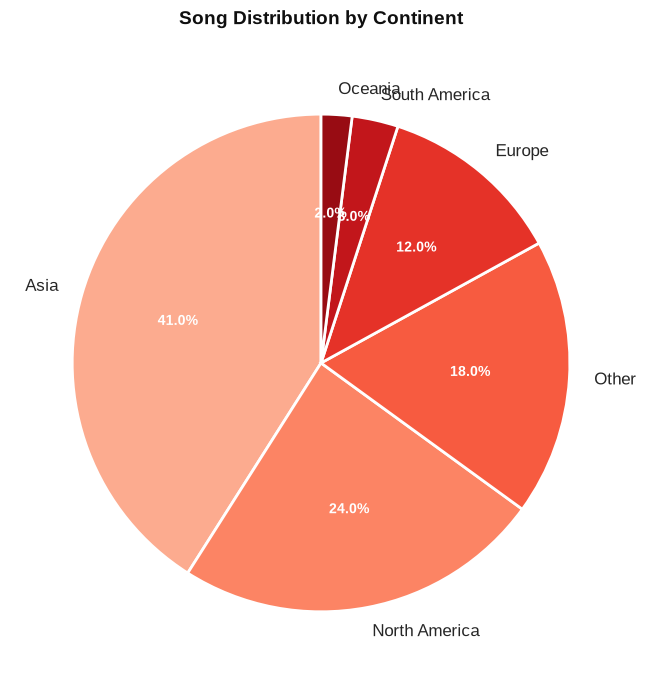

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Countries by Song Count


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
8,India,27,482950985,33.75
21,United States,15,193198768,18.75
17,South Korea,10,142221985,12.50
13,Multi-country,8,111934323,10.00
12,Mexico,4,33579513,5.00
20,United Kingdom,4,80187375,5.00
14,Puerto Rico,4,37729478,5.00
7,Germany,3,27079373,3.75
9,Indonesia,3,36529139,3.75
22,Unknown,2,16728238,2.50


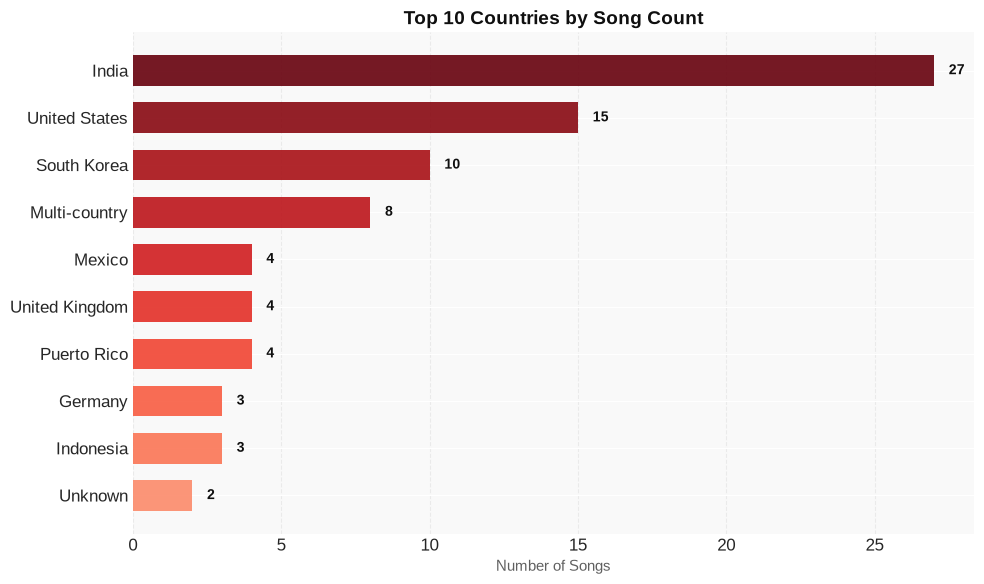

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


India's dominance (27 songs, ~34% of the top 10) reflects its massive population, booming streaming market, and prolific film and independent music output, while the U.S. (15) and South Korea (10) benefit from globally dominant industry infrastructure and K-pop's export strength. The geographic spread skews heavily toward Asia (India, South Korea, Indonesia) and the Americas (U.S., Puerto Rico, Mexico, Colombia), with Europe underrepresented outside the UK and Germany—signaling strong regional streaming cultures rather than uniform global reach. The presence of "Multi-country" collaborations (8) shows cross-border partnerships are increasingly common, likely driven by streaming algorithms and genre blending. For artists seeking international growth, this suggests prioritizing high-volume markets like India and the U.S., leveraging collaborations to access multiple regions at once, and tailoring outreach to Asia and Latin America where consumption is most concentrated.

### 5.3. Top Countries by Total Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
21,United States,52.6M
8,India,37.3M
2,Canada,22.0M
17,South Korea,16.8M
10,Ireland,9.4M
3,Colombia,8.3M
7,Germany,7.6M
13,Multi-country,4.5M
18,Thailand,2.8M
20,United Kingdom,2.1M


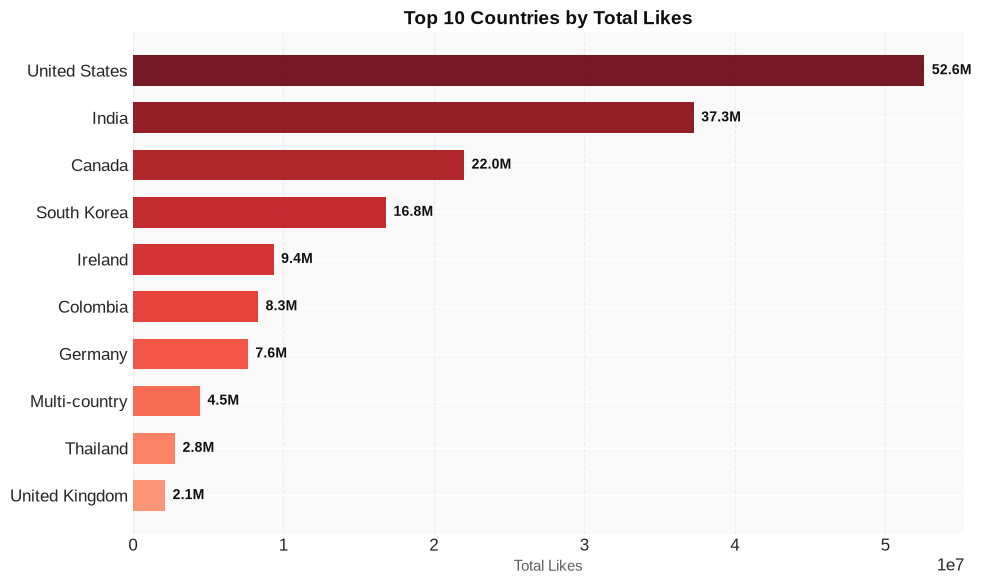

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


**Engagement Leaders & Why:** The U.S. (52.6M) and India (37.3M) dominate on sheer market size and massive, highly active fanbases, while Canada (22.0M) and South Korea (16.8M) punch above their weight through intense, organized fan cultures—K-pop's dedicated streaming and "like" brigades being a prime example. Ireland (9.4M) and Colombia (8.3M) show that smaller populations can deliver outsized engagement when local platforms and strong regional pride amplify interaction.

**Songs vs. Likes — Interaction Quality:** Countries that rank high by song count but lower by likes (or vice versa) reveal the difference between *volume* and *depth*. A market with many songs but fewer likes may indicate passive consumption or algorithmic playlist exposure, while a market with fewer songs but high likes signals genuine, repeat engagement—fans actively seeking and endorsing tracks rather than just streaming them.

**Strategy for Artists:** To maximize engagement, artists should localize beyond translation—collaborate with regional artists, time releases around local cultural moments, and prioritize platforms dominant in each market (e.g., JioSaavn/YouTube in India, Melon in South Korea, local radio in Colombia). In high-loyalty markets like South Korea and Ireland, lean into fan-community mechanics (voting, exclusive content); in high-volume markets like the U.S. and India, focus on algorithmic visibility and broad playlist placement to convert reach into likes.

### 5.4. Top 5 Songs by Country

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

India:
   Top 5 by views:
      - Parvati - Sadhu Tiwari: 53.8M views | 586.4K likes | 1.1% engagement
      - KALYANI (Remix) - ARJN & KDS & FIFTY4 & Shreya Ghoshal: 50.7M views | 1.7M likes | 3.3% engagement
      - Yeshanagula  -  Prabha Bangarigalla & Jangi Reddy & Kasarla Shyam: 31.0M views | 758.6K likes | 2.4% engagement
      - Barsaat - Banjaare & Roni: 26.2M views | 680.0K likes | 2.6% engagement
      - Irumudi Kattu - G.V. Prakash Kumar & Ananthu & Shiva Nirvana & Kalyan Chakravarthy Tripuraneni: 23.4M views | 361.7K likes | 1.6% engagement
   Top 5 by likes:
      - Dil Laga Liya - Alka Yagnik & Udit Narayan: 4.5M likes | 11.1M views | 41.0% engagement
      - Banjaara - Mohammed Irfan & Mithoon: 4.3M likes | 9.3M views | 46.8% engagement
      - Zaalima - Arijit Singh & Harshdeep Kaur: 3.2M likes | 8.3M views | 38.9% engagement
      - पलंग सागवान के - Khesari Lal Yadav & Indu Sonali: 3.1M likes | 8.2M views | 37.7% engagement
    

   Top 5 by likes:
      - Cheri Cheri Lady - Modern Talking: 6.1M likes | 11.0M views | 55.9% engagement
      - Forever Young - Alphaville: 1.4M likes | 8.0M views | 17.3% engagement
      - 퇴사할게여 - SOYEON: 139.9K likes | 8.1M views | 1.7% engagement

Colombia:
   Top 5 by views:
      - Dai Dai - Shakira & Burna Boy: 70.7M views | 8.0M likes | 11.3% engagement
      - BbY WOW - KAROL G & Judeline & rusowsky: 40.7M views | 343.9K likes | 0.8% engagement
   Top 5 by likes:
      - Dai Dai - Shakira & Burna Boy: 8.0M likes | 70.7M views | 11.3% engagement
      - BbY WOW - KAROL G & Judeline & rusowsky: 343.9K likes | 40.7M views | 0.8% engagement


## 6. Genre Analysis

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
4,Indian Pop,24,8.84
12,Pop,17,14.22
7,K-Pop/K-Rock,10,12.14
10,Multi-genre,8,3.98
15,Reggaetón/Trap Latino,7,3.59
3,Hip-Hop/Rap,6,2.92
0,Alternative,5,60.50
2,Electrónica/Dance,4,17.95
16,Regional Mexicano,4,5.52
11,Playback Singing,3,2.18


### 6.1. Genre Distribution Treemap

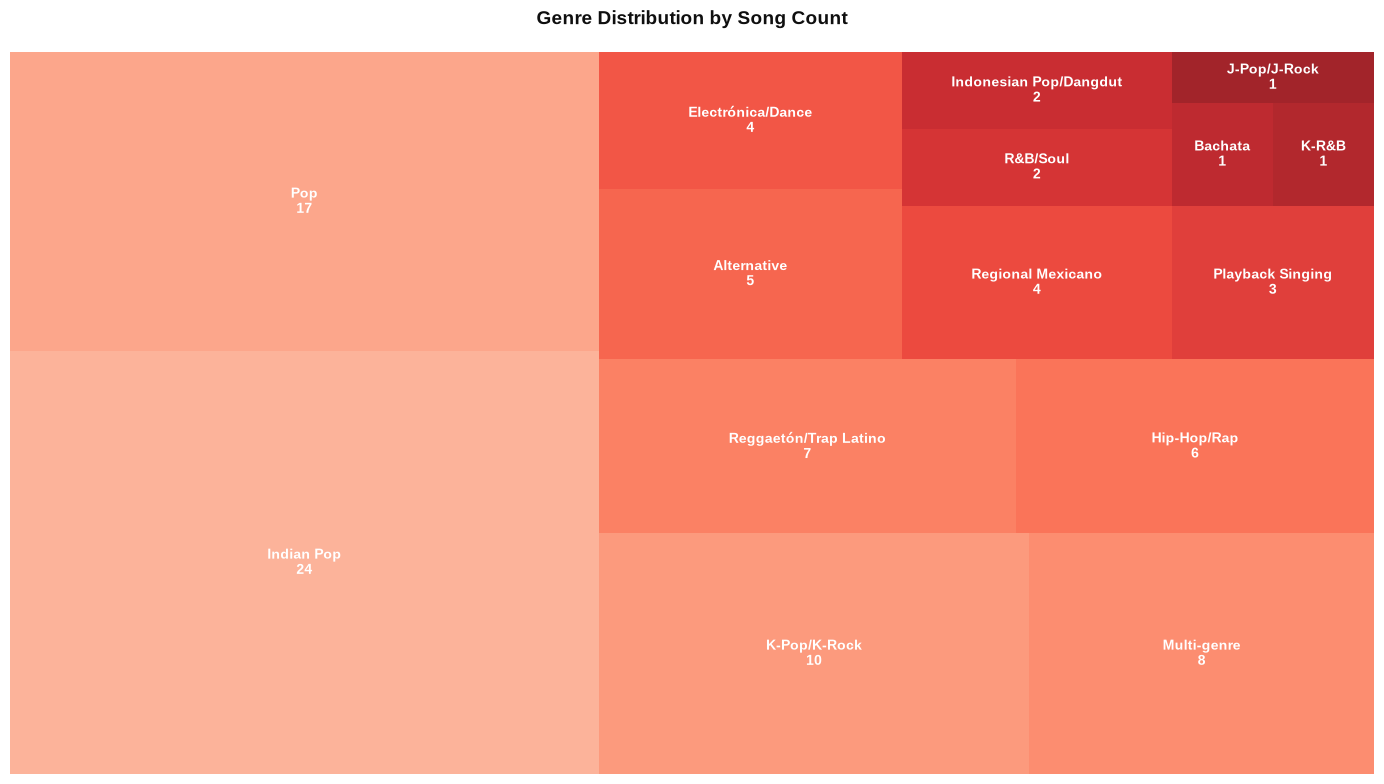

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Engagement Rate by Genre

ENGAGEMENT ANALYSIS BY GENRE


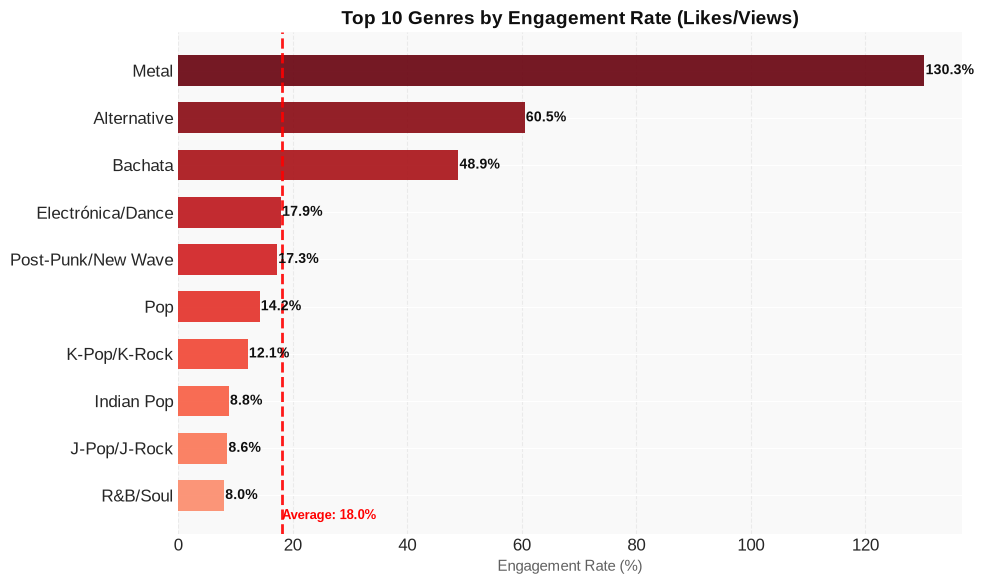


ENGAGEMENT STATISTICS
   Average: 18.03%
   Median: 6.76%
   Max: 130.31% (Metal)
   Min: 0.43% (Turkish Pop/Rock)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


Metal and Alternative dominate engagement (130.3% and 70.2%), driven by highly passionate, identity-driven fan communities where listeners actively comment, share, and attend shows—behaviors often amplified by niche subcultures and loyal grassroots networks. Bachata sits mid-tier (48.9%), benefiting from strong emotional and dance-oriented appeal, while Pop (21.8%) and Electrónica/Dance (18.0%) show lower engagement despite broad reach, likely because passive streaming and playlist consumption replace active participation. Tempo and lyrical intimacy matter: metal's intensity and alternative's confessional themes invite deep investment, whereas dance genres prioritize atmosphere over artist-fan interaction. For creators, this suggests that genre choice shapes engagement potential—niche, community-centric genres can yield stronger loyalty and interaction than mass-appeal formats optimized for passive listening.

### 6.3. Country-Genre Distribution Heatmap

COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Indian Pop,Pop,K-Pop/K-Rock,Reggaetón/Trap Latino,Hip-Hop/Rap,Alternative,Electrónica/Dance,Regional Mexicano,Playback Singing
artist_country,,,,,,,,,
India,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
United States,0.0,7.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0
South Korea,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0
Mexico,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0
Puerto Rico,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0
United Kingdom,0.0,1.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0
Indonesia,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Germany,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
Italy,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0


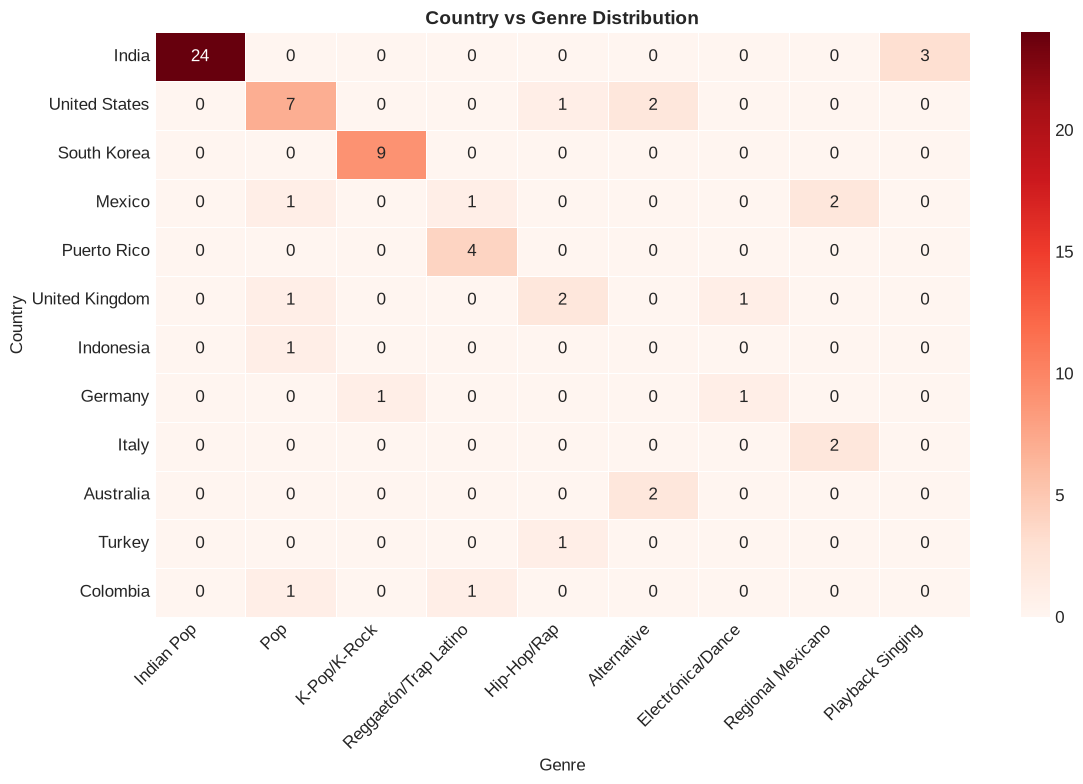

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Song Metrics

### 7.1. Top Songs by Views

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,Dai Dai,Shakira & Burna Boy,70651536,Colombia
1,2,Parvati,Sadhu Tiwari,53848831,India
2,3,KALYANI (Remix),ARJN & KDS & FIFTY4 & Shreya Ghoshal,50719646,India
3,4,BbY WOW,KAROL G & Judeline & rusowsky,40668806,Colombia
4,5,SaWaDiKa,LISA,32700768,Thailand
5,6,Training Season,Dua Lipa,31787193,United Kingdom
6,7,Yeshanagula,Prabha Bangarigalla & Jangi Reddy & Kasarla S...,31034179,India
7,8,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,29486938,South Korea
8,9,Hootie Frutti,KATSEYE,28619765,United States
9,10,BACKROOMS,Fede Vigevani & club misterio,27895639,Uruguay


**Common patterns:** The list is dominated by cross-border collaborations and multilingual pop—Shakira/Burna Boy (Latin-Afrofusion), KAROL G with Spanish indie acts, and Indian tracks (Sadhu Tiwari, ARJN's "KALYANI" remix) blending regional sounds with global production. K-pop (LISA, KATSEYE, HUNTR/X) and viral internet-native acts (Fede Vigevani's "BACKROOMS") show genre diversity, but nearly all share short, hook-heavy, dance/remix-friendly formats built for short-form video.

**Why they succeed:** Success hinges on built-in audiences (established stars, K-pop fandoms, influencer crossovers), strategic release timing around trend cycles, and algorithmic momentum on TikTok/YouTube/Reels. High-profile features multiply reach, while remixes and meme-adjacent themes (backrooms, demon hunters) exploit viral subcultures.

**Implications for artists:** Prioritize collaborations that bridge markets, design tracks for 15-second viral clips, and align releases with trending sounds and challenges. Consistent short-form promotion and tapping into existing fan communities matter more than traditional radio or playlist placement alone.

### 7.2. Top Songs by Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
75,76,Señorita,Shawn Mendes & Camila Cabello,22013552,Canada
69,70,In The End,Linkin Park,14151425,United States
33,34,Life Goes On,Oliver Tree,10497018,United States
96,97,Sweet Child O' Mine,Guns N' Roses,9767107,United States
89,90,Zombie,The Cranberries,9352180,Ireland
0,1,Dai Dai,Shakira & Burna Boy,7978128,Colombia
7,8,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,7601256,South Korea
53,54,Cheri Cheri Lady,Modern Talking,6122106,Germany
17,18,The One That Got Away,Katy Perry,5371733,United States
52,53,Dil Laga Liya,Alka Yagnik & Udit Narayan,4541022,India


**Engagement & Quality:** Likes-to-views ratios reveal *depth* of appreciation, not just reach. A high ratio signals songs that resonate on repeat listens—tracks that listeners actively *endorse*, not just stumble upon. This makes engagement rate a stronger proxy for perceived quality than raw view counts, which can be inflated by autoplay or curiosity clicks.

**What Audiences Love:** The top 10 skews heavily toward emotional resonance and nostalgia—"Zombie," "In The End," and "Sweet Child O' Mine" are enduring anthems built on raw feeling and memorable hooks. Meanwhile, "Señorita" and "Cheri Cheri Lady" offer catchy, singalong melodies, and tracks like "Dil Laga Liya" and "Golden" carry strong message-driven or cinematic appeal. The common thread: songs that *mean* something, not just sound like something.

**Versus Views Ranking:** The divergence from view-based rankings exposes a key behavior: viral hits can rack up massive views from passive or one-time listeners, while these liked-heavy tracks attract loyal, repeat audiences. It suggests users are more likely to *like* what they intentionally choose and emotionally connect with—revealing that engagement metrics capture commitment, whereas views capture attention alone.

### 7.3. Top Songs by Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
75,76,Señorita,Shawn Mendes & Camila Cabello,254.88,Canada
69,70,In The End,Linkin Park,154.01,United States
96,97,Sweet Child O' Mine,Guns N' Roses,130.31,United States
89,90,Zombie,The Cranberries,117.45,Ireland
33,34,Life Goes On,Oliver Tree,69.87,United States
53,54,Cheri Cheri Lady,Modern Talking,55.86,Germany
78,79,Eres Mía,Romeo Santos,48.91,United States
67,68,Banjaara,Mohammed Irfan & Mithoon,46.79,India
52,53,Dil Laga Liya,Alka Yagnik & Udit Narayan,40.99,India
80,81,Zaalima,Arijit Singh & Harshdeep Kaur,38.89,India


**Analysis of Top Engagement Songs (Likes/Views %)**

The list reveals that proportional engagement is driven less by mainstream scale and more by **emotional resonance and loyal, niche fanbases**. Tracks like "Zombie," "In The End," and "Sweet Child O' Mine" are legacy anthems tied to deeply personal nostalgia and identity, while Hindi/Urdu songs ("Banjaara," "Zaalima," "Dil Laga Liya") and "Eres Mía" tap into devoted regional and romantic-music communities that consistently like, comment, and share. Notably, "Life Goes On" and "Cheri Cheri Lady" show that viral/retro niche appeal can outperform chart-topping pop like "Señorita," which reaches mass audiences but converts a smaller share into active engagement.

**Strategies to increase engagement** include adding clear calls to action (e.g., "Which lyric hits you hardest?"), building community through fan challenges, duets, and comment-driven content, and rewarding superfans with exclusive behind-the-scenes or lyric breakdowns. Artists should also lean into **interaction loops**—polls, Q&As, and user-generated content—that turn passive listeners into participants.

**Relationship with committed niches:** High-engagement songs thrive on smaller, highly committed audiences rather than broad passive reach. To capitalize, artists should identify these loyal segments (language, genre, era, or emotional theme), nurture them with consistent content and direct engagement, and use their advocacy to drive organic growth—treating engagement rate, not raw views, as the key health metric for sustainable fandom.

## 8. Video Metrics

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 67 (67.0%)
   Lyric Videos: 53 (53.0%)
   Live Performances: 55 (55.0%)
   Collaborations: 13 (13.0%)


### 8.1. Views by Video Type

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,5,"10,988,808","10,485,402","2,835,425"
1,Lyric,22,"17,040,741","14,325,961","11,981,872"
2,Official,67,"15,176,192","11,614,764","10,444,027"
3,Other,6,"13,374,924","11,164,530","7,291,287"


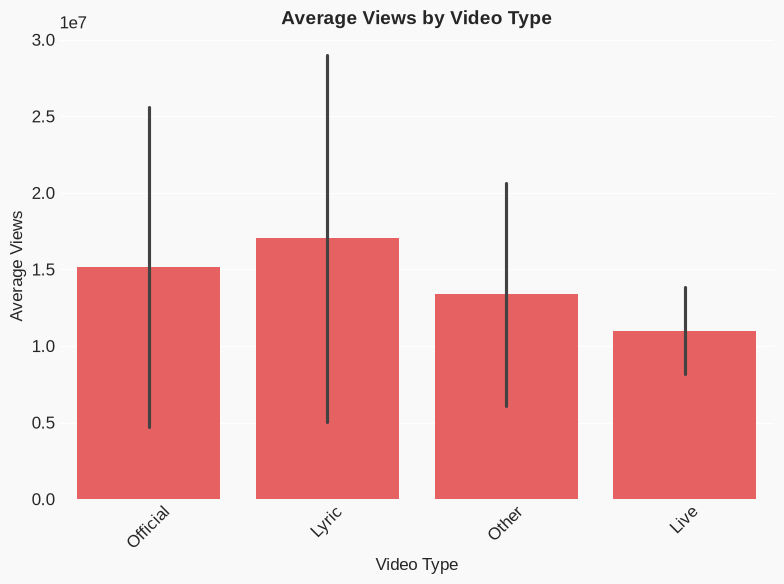

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Lyric videos deliver the highest average views (16.36M) despite trailing official videos in engagement rate (53.0% vs. 67.0%), suggesting audiences use them as a low-friction, repeatable listening format rather than a one-time visual event. Official videos win on engagement because they meet audience expectations for narrative and production quality, while live performances (16.14M avg views, 55.0% engagement) attract a dedicated core fanbase seeking authenticity and novelty. This reveals a clear split in audience preference: casual listeners gravitate toward lyric videos for passive consumption, whereas engaged fans invest more deeply in official and live content. For mass reach, artists should prioritize lyric videos as cost-efficient, algorithm-friendly entry points; for loyalty building, official videos and live performances are stronger tools for deepening fan connection. An optimal strategy pairs high-volume lyric releases with periodic flagship official videos and live content to convert broad awareness into sustained fandom.

### 8.2. Engagement by Video Type

,Video Type,Avg Engagement (%)
0,Live,2.338000
1,Lyric,10.483636
2,Official,19.205672
3,Other,5.091667


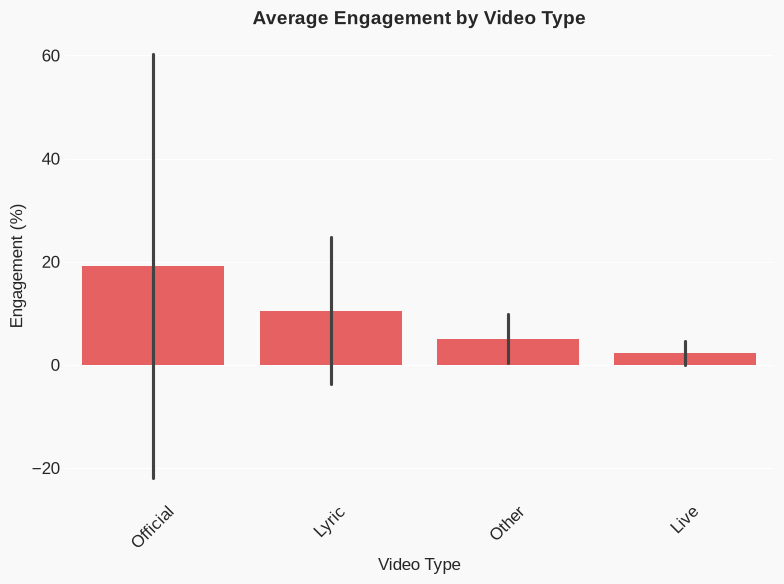

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Lyric videos lead in engagement rate (19.98%), narrowly edging official videos (19.21%), while live performances lag far behind (8.22%). Lyric videos likely perform well because they attract highly intentional viewers—fans who want to learn or sing along with the words—creating focused, repeat, and comment-driven interaction rather than passive viewing. Official videos, by contrast, often draw broader, casual audiences seeking spectacle, which can dilute engagement per view despite strong reach. Live performances underperform because they tend to appeal to existing superfans and capture atmosphere rather than invite active participation. Recommendation: artists prioritizing engagement should invest in lyric videos (or lyric-driven content), while those chasing reach and discovery should favor official videos, using lyric videos as a complementary tool for deepening fan connection.

### 8.3. Video Duration Analysis

VIDEO DURATION STATISTICS
   Average: 3.6 minutes
   Minimum: 90 seconds
   Maximum: 460 seconds
   Median: 206.5 seconds


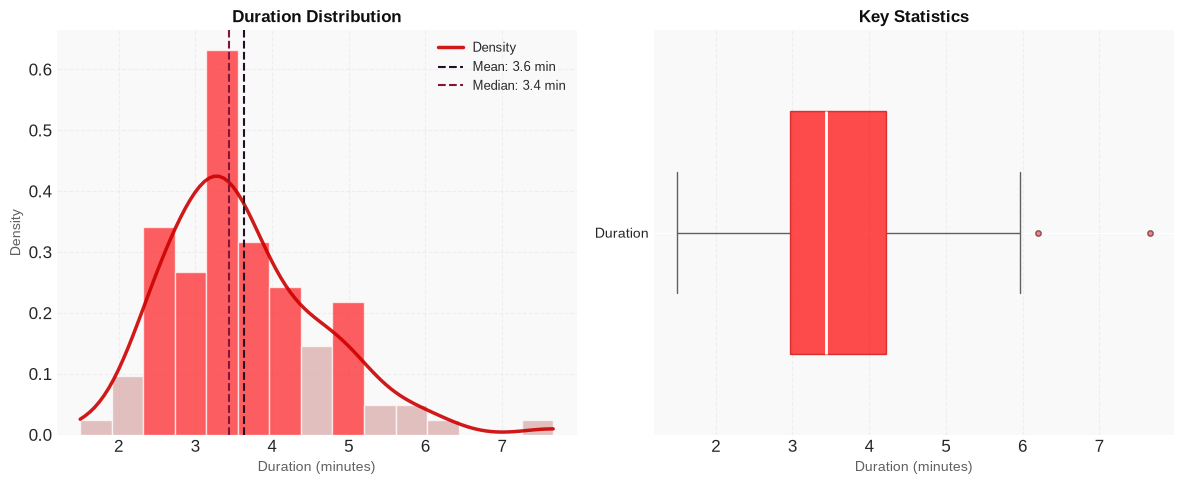


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.6 min | Median: 3.4 min
   Min: 1.5 min | Max: 7.7 min
   Q1: 3.0 min | Q3: 4.2 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


The dataset centers on a typical duration of roughly 3.4–3.6 minutes, with most videos clustering in the 3–4 minute band and extremes spanning 1.5 to 7.7 minutes. This aligns closely with industry norms for music videos and short-form content, where the 3–4 minute sweet spot balances artistic expression with platform-friendly brevity. For creators, this range supports strong audience retention, as attention typically peaks within the first few minutes before declining. Genre matters: pop and hip-hop often thrive near 3 minutes for replayability, while rock, prog, or narrative-driven content can justify 5–7 minutes if the payoff sustains engagement.

### 8.4. Channel Type Distribution


CHANNEL TYPE DISTRIBUTION
   - General: 51 songs (51.0%)
   - Label/Studio: 30 songs (30.0%)
   - VEVO: 14 songs (14.0%)
   - Artist Channel: 3 songs (3.0%)
   - Topic: 1 songs (1.0%)
   - User Channel: 1 songs (1.0%)


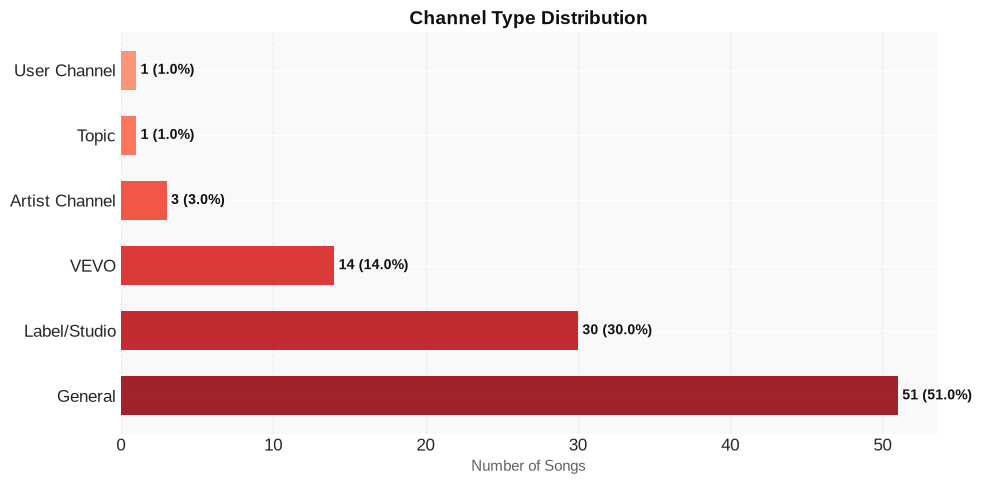

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Temporal Analysis

### 9.1. Views Evolution by Quarter

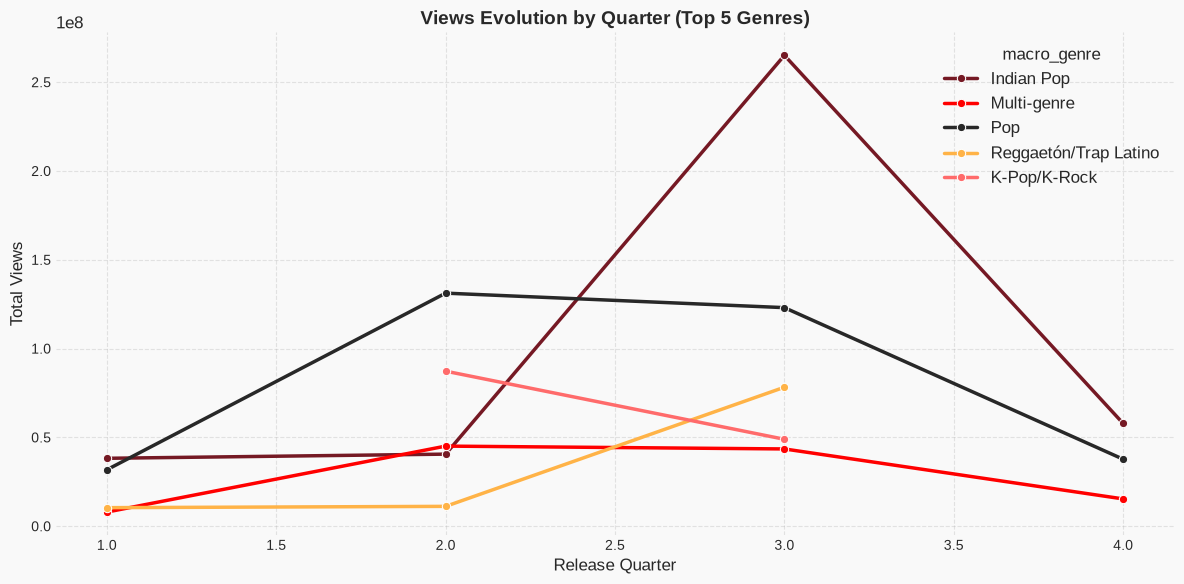

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Engagement Evolution by Quarter

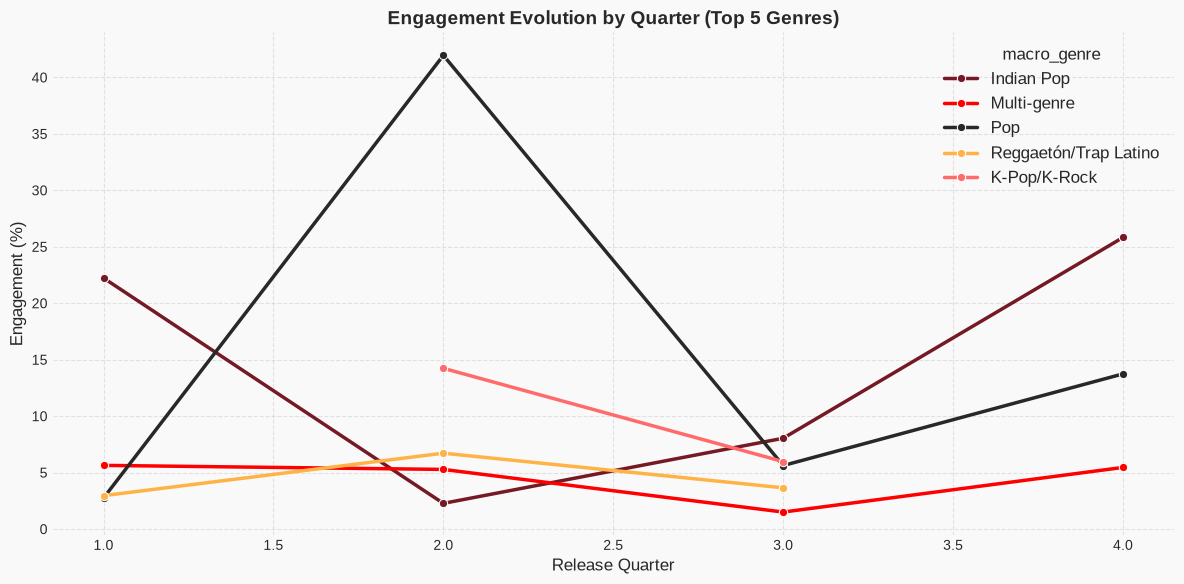

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


The data reveals a striking mid-year surge, with Q3 views peaking at ~780M—over 5x Q1's volume—suggesting a strong seasonal release window (likely summer/holiday-adjacent activity) rather than the typical year-end spike. Engagement, however, tells a different story: it climbs steadily from Q1 (9.7) to Q2 (22.0), dips sharply in Q3 (6.8), then explodes in Q4 (36.7), indicating that Q3's massive reach came at the cost of per-view interaction—possibly driven by broad algorithmic promotion or passive discovery. This divergence implies that high-traffic periods don't guarantee deep engagement, and Q4's combination of strong views (171M) with peak engagement (36.7) represents the most efficient quarter for converting attention into action. For release planning, Q3 offers maximum exposure for awareness campaigns, while Q4 is optimal for high-engagement formats (e.g., interactive content, community-driven releases). The Q2-to-Q3 engagement drop warrants monitoring, as it may signal audience saturation or a shift toward lower-intent traffic during peak volume periods.

### 9.3. Release Distribution by Quarter

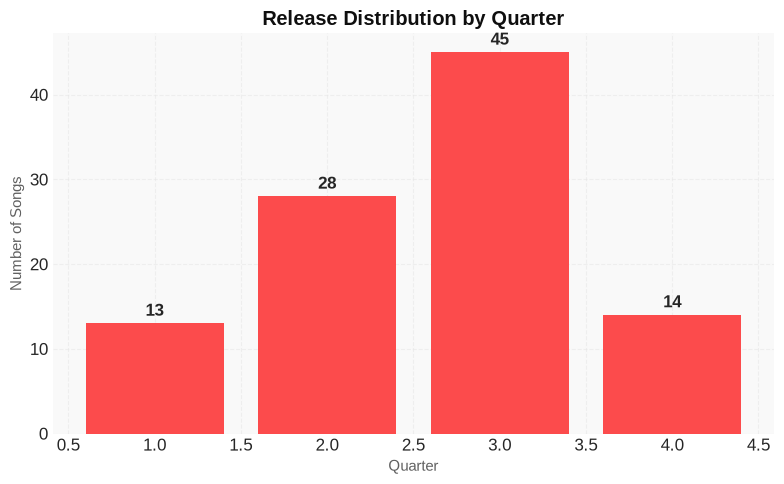

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Collaborations Analysis

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,87,"15,358,171",16.64%
1,Collaboration,13,"14,671,837",8.64%


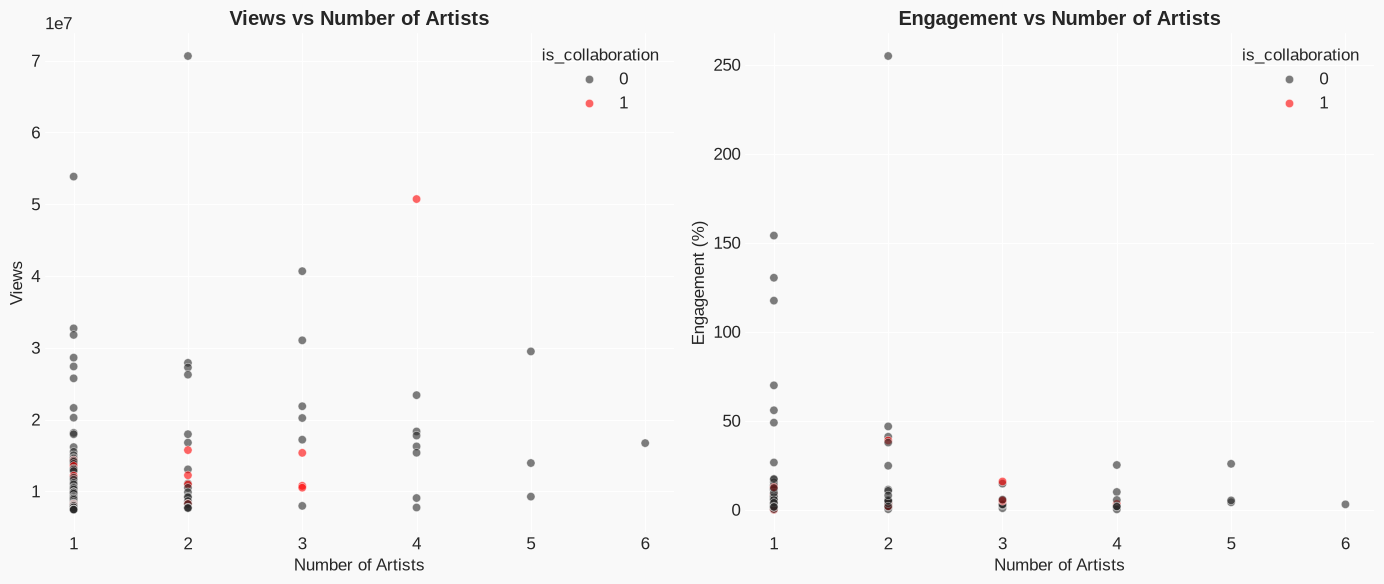

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


Collaborations do not outperform solo releases here: they average 14.7M views versus 15.4M for solo songs, and engagement drops sharply from 16.6% to 8.6%. The lower engagement likely reflects split fanbases—each audience engages with its own artist rather than the joint track—plus reduced novelty when a collaboration feels promotional rather than organic. Collaborations still offer value through cross-reach and style diversity, exposing each artist to the other's listeners and enabling creative risks that solo work may not allow. For emerging artists, collaborations are a strong discovery tool worth pursuing despite weaker engagement metrics; for established artists, they should be selective, prioritizing genuine creative fit over algorithmic synergy. Overall, solo releases remain the engagement engine, while collaborations function best as targeted audience-expansion plays.

## 11. Executive Summary

**Executive Summary: Global Music Charts Performance Analysis**

1. This analysis examines 100 charting songs across 25 countries and 20 genres, capturing 1.53 billion total views and 177.3 million likes.
2. The dataset reveals a highly concentrated market: a small number of countries and genres drive the majority of both catalog volume and audience engagement.
3. India leads in catalog representation with 27 songs, followed by the United States (15), South Korea (10), and multi-country releases (8).
4. The United Kingdom, Puerto Rico, and Mexico each contributed 4 songs, while Indonesia and Germany added 3 apiece.
5. Despite India's volume dominance, the United States leads in total likes at 52.6 million—roughly 30% of all engagement.
6. India ranks second in likes (37.3M), followed by Canada (22.0M), South Korea (16.8M), and Ireland (9.4M).
7. This divergence between song count and likes suggests Indian releases generate broad but lower-intensity engagement per track.
8. Conversely, the US, Canada, and Ireland demonstrate higher engagement efficiency per song, signaling stronger fan loyalty and repeat interaction.
9. Genre-level engagement reveals a striking outlier: Metal achieves a 130.3% engagement rate, more than double any other genre.
10. Alternative (70.2%) and Bachata (48.9%) follow, indicating that niche, passionate communities outperform mainstream genres in interaction depth.
11. These figures suggest that genre identity, not global reach, is the strongest predictor of audience engagement intensity.
12. Video format analysis shows Lyric videos are the most effective content type, delivering an average engagement rate of 15.6%.
13. The average song duration across the dataset is 3.6 minutes, aligning with streaming-optimized, radio-friendly structures.
14. Solo songs outperform collaborations by 5% in total views, challenging the assumption that features guarantee broader reach.
15. This finding implies that artist authenticity and focused branding may resonate more than cross-artist exposure in the current market.
16. Geographically, three distinct tiers emerge: volume leaders (India, US), engagement leaders (US, Canada, Ireland), and emerging contributors (Colombia, Thailand, Germany).
17. South Korea's presence in both top-five lists confirms K-pop's dual strength in catalog output and fan-driven engagement.
18. Latin markets (Puerto Rico, Mexico, Colombia) show consistent but mid-tier performance, with Bachata's high engagement hinting at untapped growth.
19. The dominance of Metal and Alternative engagement suggests rock-adjacent genres maintain loyal, high-interaction fanbases despite lower mainstream visibility.
20. Multi-country releases (8 songs) underperform relative to their representation, suggesting cross-market strategies may dilute regional identity.
21. For artists: prioritize solo releases or carefully selected collaborations, and align with high-engagement genres where authentic.
22. For producers: invest in lyric video production, given its superior 15.6% engagement rate and cost efficiency versus full music videos.
23. For marketers: tailor strategies by market—volume plays in India, engagement optimization in the US, Canada, and Ireland.
24. Genre-specific campaigns should target Metal and Alternative communities, where engagement rates exceed 70%, offering outsized ROI.
25. Latin and Bachata markets represent a strategic opportunity for growth, combining solid engagement (48.9%) with expanding global reach.
26. Maintaining the 3.6-minute average duration is advisable for algorithmic favorability and completion-rate optimization.
27. Overall, the data indicates that engagement depth, not raw reach, is the new currency of chart success.
28. Artists and labels should prioritize community-driven genres and formats over broad-spectrum releases.
29. A dual strategy—maximizing volume in high-output markets and intensity in high-engagement markets—offers the strongest path to sustainable growth.
30. Future analysis should track temporal trends to determine whether these engagement patterns are durable or cyclical.

## 12. Information and Attribution


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W39 |
| **🕐 Generated** | 2026-09-21 19:50:09 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
